<a href="https://colab.research.google.com/github/sskarthik0801/ME-597-IIOT/blob/main/ml_tutorial/HW/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Homework 3 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW3.ipynb" to "HW3_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together

# [HW 3] Customize the ANN

1. Load dataset resulted from ML3_Code2 (FeatureSelected) and create corresponding labels referring to ML5_Code1.

2. Design and train a customized ANN model according to the following instructions:

- Set the learning rate to 0.01.
- Set the number of hidden layers to 3.
- Set the number of neurons in the first hidden layer to 15.
- Set the number of neurons in the second hidden layer to 10.
- Set the number of neurons in the third hidden layer to 5.
- Set the number of training epochs to 300.
- Set the activation function differently from the ML5 code by referring to the link provided in the code. (Few functions may not work due to compatibility issues, please try other functions in that case.)
- Set the loss function and optimization algorithm differently from the ML5 code by referring to the link provided. (Few functions may not work due to compatibility issues, please try other functions in that case.)

3. Plot a graph of the training process (Loss, Accuracy) at the end.

In [1]:
'''mount google drive'''
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


FeatureSelected shape: (29, 360)
Data shape: (360, 29)
TrainData shape: (360, 29)
TrainLabel shape: (360, 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 15)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677 (2.64 KB)

 Trainable params: 677 (2.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4716 - loss: 0.8000 - val_accuracy: 0.7778 - val_loss: 0.5275
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7518 - loss: 0.5280 - val_accuracy: 0.9167 - val_loss: 0.3733
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8940 - loss: 0.3924 - val_accuracy: 0.9861 - val_loss: 0.2893
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9380 - loss: 0.3082 - val_accuracy: 0.9861 - val_loss: 0.2385
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9705 - loss: 0.2534 - val_accuracy: 0.9861 - val_loss: 0.2045
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9889 - loss: 0.2153 - val_accuracy: 1.0000 - val_loss: 0.1800
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9859 - loss: 0.1891 - val_accuracy: 1.0000 - val_loss: 0.1613
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9906 - loss: 0.1713 - val_accuracy: 1.0000 - val_loss:

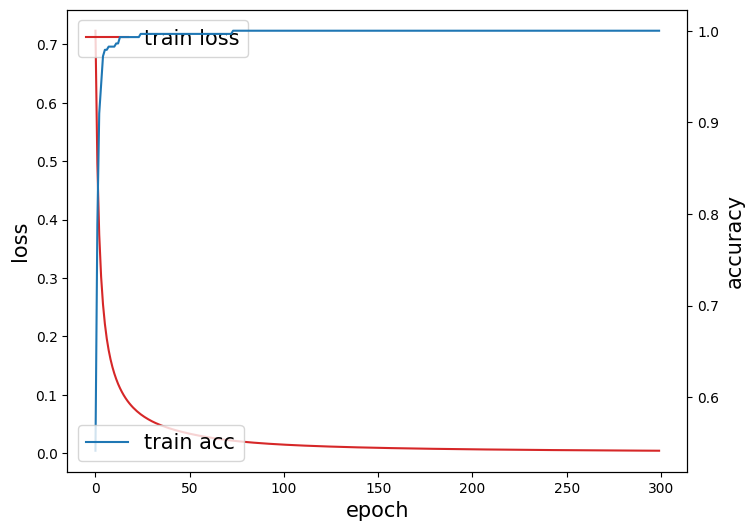

In [3]:
# Start with importing packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD


# Load FeatureSelected Dataset


data_path = "/content/drive/MyDrive/Colab Notebooks/SavedFiles/FeatureSelected.csv"

FeatureSelected = pd.read_csv(data_path)

print("FeatureSelected shape:", FeatureSelected.shape)

# Dataset format: features × samples
# So transpose it to: samples × features
Data = FeatureSelected.values.T

print("Data shape:", Data.shape)


# One-hot Labeling (ML5 style)

NumSamples = Data.shape[0]
Half = int(NumSamples/2)

# Split Normal / Abnormal
TrainData_Nor = Data[:Half]
TrainData_Abn = Data[Half:]

# Labels
TrainLabel_Nor = np.zeros((TrainData_Nor.shape[0],2))
TrainLabel_Nor[:,0] = 1   # [1,0] Normal

TrainLabel_Abn = np.zeros((TrainData_Abn.shape[0],2))
TrainLabel_Abn[:,1] = 1   # [0,1] Abnormal

# Combine
TrainData  = np.concatenate([TrainData_Nor , TrainData_Abn ], axis=0)
TrainLabel = np.concatenate([TrainLabel_Nor, TrainLabel_Abn], axis=0)

print("TrainData shape:", TrainData.shape)
print("TrainLabel shape:", TrainLabel.shape)

# Normalize Data


scaler = StandardScaler()
TrainData = scaler.fit_transform(TrainData)

# Build Customized ANN

model = Sequential()

# Hidden Layer 1 (15 neurons)
model.add(Dense(15, activation='tanh', input_shape=(TrainData.shape[1],)))

# Hidden Layer 2 (10 neurons)
model.add(Dense(10, activation='tanh'))

# Hidden Layer 3 (5 neurons)
model.add(Dense(5, activation='tanh'))

# Output Layer
model.add(Dense(2, activation='softmax'))


# Compile Model

optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train ANN

history = model.fit(
    TrainData,
    TrainLabel,
    epochs=300,
    validation_split=0.2,
    verbose=1
)

# Plot Training Process

fig, loss_ax = plt.subplots(figsize=(8,6))

acc_ax = loss_ax.twinx()

loss_ax.plot(history.history['loss'], label='train loss', c='tab:red')
loss_ax.set_xlabel('epoch', fontsize=15)
loss_ax.set_ylabel('loss', fontsize=15)
loss_ax.legend(loc='upper left', fontsize=15)

acc_ax.plot(history.history['accuracy'], label='train acc', c='tab:blue')
acc_ax.set_ylabel('accuracy', fontsize=15)
acc_ax.legend(loc='lower left', fontsize=15)

plt.show()
# Check the training process (Loss, Accuracy)

## ML5 and ML6 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML5 and ML6.

---

ML5 and ML6 focused on applying machine learning techniques to classify machine conditions using extracted sensor features. In ML5, an ANN model was introduced to perform classification between normal and abnormal machine states using labeled datasets and one-hot encoding. In ML6, the ANN model was customized by modifying hyperparameters such as the number of hidden layers, neurons, learning rate, activation functions, and training epochs. The training process and model performance were analyzed using loss and accuracy plots.

---

### Q2. What skills did you have to develop to accomplish this project?

---
This project required developing skills in Python programming, data preprocessing, one-hot encoding for labeling, and implementing neural networks using deep learning libraries. Additionally, it involved understanding model training, hyperparameter tuning, and visualizing training performance using plots.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

The most beneficial aspect of this project was learning how machine learning models, particularly neural networks, can be used to classify machine conditions based on sensor data. It provided practical experience in building, training, and evaluating ANN models and understanding how different model parameters influence performance.

---

### Q4. What challenges did you encounter in completing the project?

---

One challenge encountered was correctly formatting and labeling the dataset for training the neural network, especially when applying one-hot encoding and combining normal and abnormal datasets. Another challenge was tuning the ANN parameters and ensuring the model trained properly without errors.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

Troubleshooting steps such as checking intermediate outputs and modifying model parameters helped ensure the ANN was trained correctly and produced meaningful results.

---